In [12]:
import numpy as np


In [14]:
#linear regression model

class linearRegression():
  #initiating the parameters (learning rate and no. of iterations)
  def __init__(self, learning_rate, iterations):
    self.learning_rate = learning_rate
    self.iterations = iterations

  def fit(self,X, Y):
    #number of traing examples and number of features
    self.m, self.n = X.shape #number of rows and columns

    #initiating the weights and bias
    self.w= np.zeros(self.n)
    self.b= 0
    self.X=X
    self.Y = Y

    #implementing gradient descent
    for i in range(self.iterations):
      self.update_weights()

  def update_weights(self):

    Y_prediction = self.predict(self.X)

    #calculate gradients

    dw = -(2 * (self.X.T).dot(self.Y - Y_prediction)) / self.m
    db = -(2 * np.sum(self.Y - Y_prediction)) / self.m

    #updating the weights

    self.w = self.w - self.learning_rate*dw
    self.b = self.b - self.learning_rate*db

  def predict(self, X):

    return X.dot(self.w) + self.b

In [1]:
#using linearRegression model for implementation

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_csv('/content/salary_data.csv')

In [4]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [5]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


In [6]:
df.shape

(30, 2)

In [18]:
#splitting features and target

x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [19]:
print(x)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]


In [57]:
# splitting in train and test set

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=2)

In [83]:
#traing the linear regression model

model = linearRegression(learning_rate=0.02, iterations=1000)

In [84]:
#fitting data in our model

model.fit(x_train, y_train)

In [85]:
#printing the parameter values (w and b)

print('weight = ', model.w[0])
print('bais = ', model.b)

weight =  9514.400999035135
bais =  23697.406507136307


In [86]:
# salary = 9534(experience) + 23735

In [87]:
#predict value for test data

test_pred = model.predict(x_test)
print(test_pred)

[ 36066.12780588  34163.24760607  66512.21100279  58900.69020357
  91249.65360029  80783.81250135 101715.49469922  52240.60950424
  42726.20850521  88395.33330058]


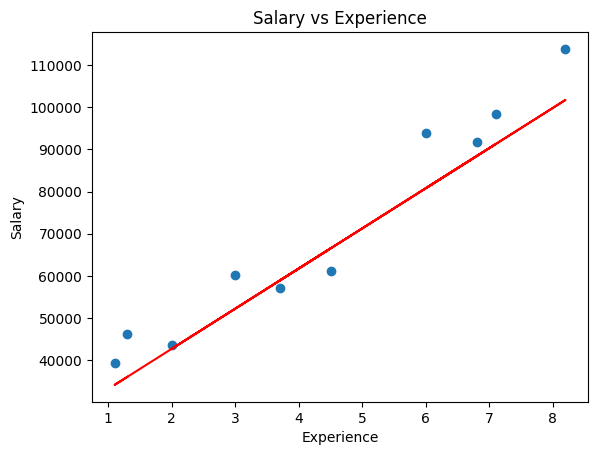

In [88]:
#plotting actual y value with predicted y value

plt.scatter(x_test, y_test)
plt.plot(x_test, test_pred, color='red')
plt.title('Salary vs Experience')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()